# Logistic Regression

Logistic Regression is a classic machine learning algorithm used for binary classification. Although its name includes "regression," it’s actually a classification model that predicts the probability of a sample belonging to a class.

Here is how it works: 

#### Linear Model:

The model computes a linear combination of the input features:

𝑧 = 𝑤1𝑥1 + 𝑤2𝑥2 + ⋯ + 𝑤𝑛𝑥𝑛 +𝑏

Where:

w = weights,

b = bias,

x = input features.

#### Sigmoid Activation:

The linear output 

z is passed through the sigmoid function to squash it between 0 and 1:

$\sigma (z) = \frac{1}{1+e^{-z}}$
 
This gives the probability that the sample belongs to the positive class.

#### Loss Function (Binary Cross-Entropy):

To train the model, we minimize the binary cross-entropy loss:

$\mathcal(L) = -\frac{1}{n} \sum_{i=1}^n (y_i \log(\hat{y}_i) + (1 - y_i)\log(1-\hat{y}_i))$

where $\hat{y}_i$ is the predicted probability and $y_i$ is the true label.

#### Gradient Descent:

We use gradient descent to iteratively update the weights and bias to minimize the loss.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

We’ll use the Breast Cancer Wisconsin dataset from sklearn.datasets

This dataset contains information about tumors, including whether they are malignant or benign, based on various features extracted from cell nuclei.

For simplicity and visualization purposes, we’ll focus on just two features:

- Mean Radius

- Mean Texture

These features create a 2D feature space, where we can visually inspect how the logistic regressor works on the data. While this choice limits visualization of the full predictive power of the dataset, it allows us to clearly observe the decision boundaries and interpret the regression results. 

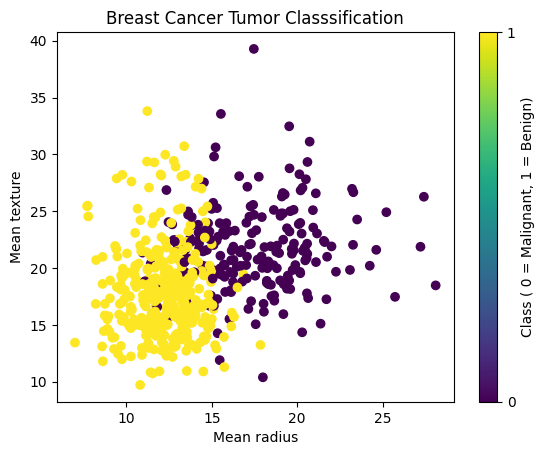

In [2]:
#Loading data
data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')  # Pick two features to plot
plt.xlabel('Mean radius')
plt.ylabel('Mean texture')
plt.title('Breast Cancer Tumor Classsification')

cbar = plt.colorbar()
cbar.set_ticks([0, 1])
cbar.set_label('Class ( 0 = Malignant, 1 = Benign)')

plt.show()

In [3]:
class SimpleLogisticRegression:
    def __init__(self, lr=0.01, n_iter=1000):
        self.lr = lr  # learning rate
        self.n_iter = n_iter  # number of iterations
        self.weights = None  # weights (will be initialized later)
        self.bias = None  # bias term

    def _sigmoid(self, z):
        # Sigmoid activation function: squashes input between 0 and 1
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        # Gradient Descent
        for _ in range(self.n_iter):
            linear_model = np.dot(X, self.weights) + self.bias
            y_predicted = self._sigmoid(linear_model)

            # Compute gradients
            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)

            # Update parameters
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict_prob(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        return self._sigmoid(linear_model)

    def predict(self, X):
        y_pred_prob = self.predict_prob(X)
        # Classify as 1 if probability >= 0.5
        return np.where(y_pred_prob >= 0.5, 1, 0)

In [4]:
#Scalling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [5]:
# Train custom logistic regression
log_reg = SimpleLogisticRegression(lr=0.01, n_iter=1000)
log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Custom Logistic Regression Accuracy: {accuracy:.4f}")

Custom Logistic Regression Accuracy: 0.9825


In [8]:
# Train sklearn logistic regression
sklearn_log_reg = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)
sklearn_log_reg.fit(X_train, y_train)
y_pred_sklearn = sklearn_log_reg.predict(X_test)
accuracy_sklearn = accuracy_score(y_test, y_pred_sklearn)
print(f"Sklearn Logistic Regression Accuracy: {accuracy_sklearn:.4f}")

Sklearn Logistic Regression Accuracy: 0.9737


In [10]:
#Comparing Results
print("\nComparison:")
print(f"Custom Logistic Regressor correct: {(y_pred == y_test).sum()} / {len(y_test)}")
print(f"Sklearn Logistic Regressor correct: {(y_pred_sklearn == y_test).sum()} / {len(y_test)}")


Comparison:
Custom Decision Tree correct: 112 / 114
Sklearn Decision Tree correct: 111 / 114


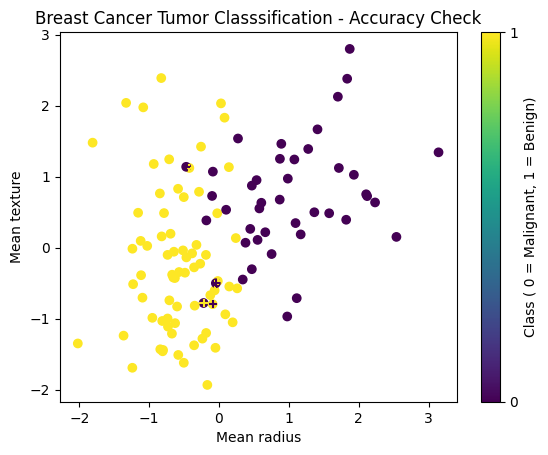

In [11]:
plt.scatter(X_test[:, 0], X_test[:, 1], c = y_pred)
plt.scatter(X_test[:, 0], X_test[:, 1], c = y_test, marker = '+')

plt.xlabel('Mean radius')
plt.ylabel('Mean texture')
plt.title('Breast Cancer Tumor Classsification - Accuracy Check')

cbar = plt.colorbar()
cbar.set_ticks([0, 1])
cbar.set_label('Class ( 0 = Malignant, 1 = Benign)')
     

The high accuracy shows that logistic regression is an excellent match for the Breast Cancer dataset, which is well-suited to linear classification.

Our custom implementation not only converged properly but even slightly outperformed sklearn’s version which is exciting and validates the accuracy of the model.